**Program to find the intrinsic camera properties using chessboard images**

Input - camera images of chessboard - and chessboard properties

Output - camera matrix

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random


In [30]:
chessboard_width = 6
chessboard_height = 9
square_size_mm = 20

print(f"Chessboard dimensions (inner corners): {chessboard_width}x{chessboard_height}")
print(f"Square size: {square_size_mm} mm")

Chessboard dimensions (inner corners): 6x9
Square size: 20 mm


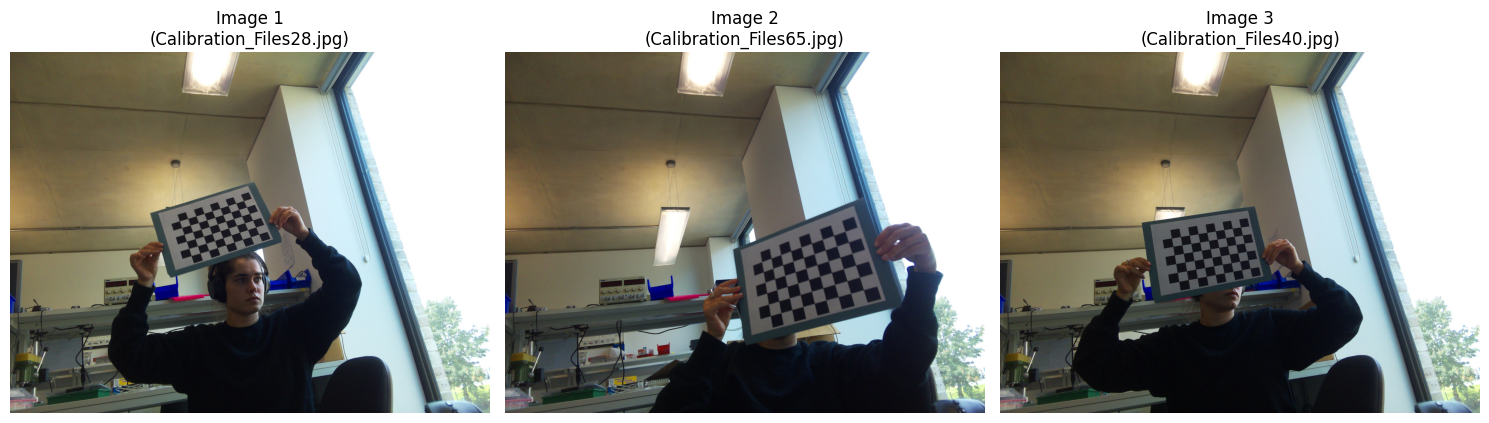

In [31]:
# check files loaded correctly
num_images_to_display = 3
random_images = random.sample(images, min(num_images_to_display, len(images)))

plt.figure(figsize=(15, 5))
for i, img_path in enumerate(random_images):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, num_images_to_display, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"Image {i+1}\n({img_path.split('/')[-1]})")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [32]:

objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.

found_corners_count = 0

# Loop through the images that were loaded from the calibration directory
for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, corners = cv2.findChessboardCorners(gray, (chessboard_width, chessboard_height), None)

    # If corners are found, refine them and add to the lists
    if ret == True:
        objpoints.append(objp) # Use the globally defined objp
        corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria) # Use globally defined criteria
        imgpoints.append(corners2)
        found_corners_count += 1
    else:
        print(f"Warning: Chessboard corners not found in {fname}")

print(f"Successfully found corners in {found_corners_count} out of {len(images)} images.")
print(f"Collected {len(objpoints)} object point sets and {len(imgpoints)} image point sets.")

Successfully found corners in 70 out of 73 images.
Collected 70 object point sets and 70 image point sets.


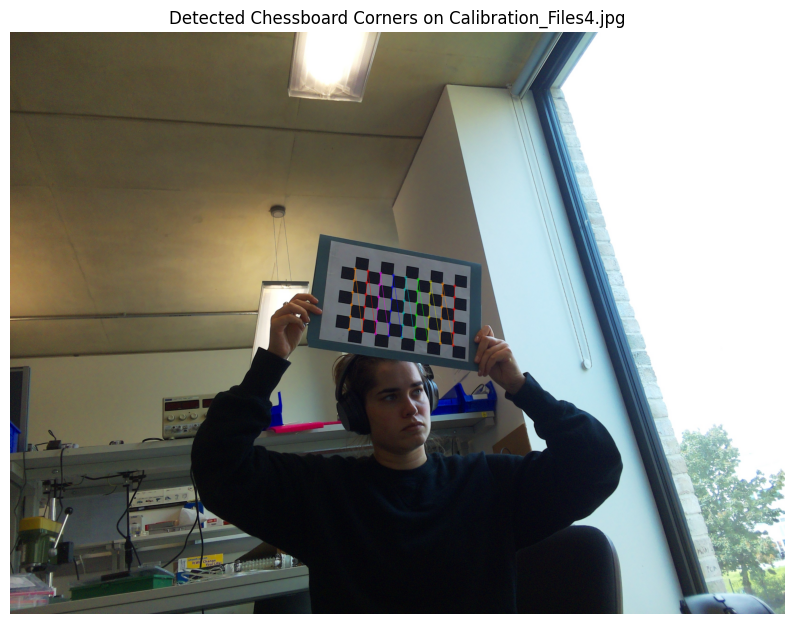

In [33]:

if len(objpoints) > 0:

    # Choose a random index from the images where corners were found
    random_idx = random.randint(0, len(objpoints) - 1)

    sample_fname = random.choice(images)

    img_original = cv2.imread(sample_fname)
    gray_sample = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)

    # Find the chessboard corners for the sample image
    ret, corners = cv2.findChessboardCorners(gray_sample, (chessboard_width, chessboard_height), None)

    if ret == True:
        corners2 = cv2.cornerSubPix(gray_sample, corners, (11, 11), (-1, -1), criteria).astype(np.float32)

        # Draw the corners on the image
        img_drawn_corners = cv2.drawChessboardCorners(img_original.copy(), (chessboard_width, chessboard_height), corners2, ret)

        # Convert to RGB for matplotlib
        img_rgb = cv2.cvtColor(img_drawn_corners, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 8))
        plt.imshow(img_rgb)
        plt.title(f"Detected Chessboard Corners on {sample_fname.split('/')[-1]}")
        plt.axis('off')
        plt.show()
    else:
        print(f"Could not detect corners on the sample image: {sample_fname}. Please try re-running the cell to pick another sample.")
else:
    print("No corners were detected in any images during calibration. Please ensure chessboard_width and chessboard_height are correct and images are clear.")

In [34]:
import numpy as np

# Pass the objpoints and imgpoints lists directly, assuming their elements are now np.float64
ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
print("Calibration successful!")
print(f"Camera Matrix:\n{mtx}")
print(f"Distortion Coefficients:\n{dist}")

Calibration successful!
Camera Matrix:
[[2.60872150e+03 0.00000000e+00 1.49382111e+03]
 [0.00000000e+00 2.58477115e+03 1.19187445e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion Coefficients:
[[ 0.13766501  0.1915688  -0.00321046 -0.02991662 -1.15638655]]


In [35]:
import numpy as np

# Define filenames
camera_matrix_filename = 'camera_matrix.txt'
dist_coeffs_filename = 'dist_coeffs.txt'

# Format camera matrix as a flattened, space-separated string
camera_matrix_flat = mtx.flatten()
np.savetxt(camera_matrix_filename, camera_matrix_flat.reshape(1, -1), fmt='%f', delimiter=' ')

# Save distortion coefficients
np.savetxt(dist_coeffs_filename, dist, fmt='%f', delimiter=' ')

print(f"Camera matrix exported to {camera_matrix_filename}")
print(f"Distortion coefficients exported to {dist_coeffs_filename}")

# Optionally, you can print the content to verify
print("\nContent of camera_matrix.txt:")
with open(camera_matrix_filename, 'r') as f:
    print(f.read())

print("\nContent of dist_coeffs.txt:")
with open(dist_coeffs_filename, 'r') as f:
    print(f.read())

Camera matrix exported to camera_matrix.txt
Distortion coefficients exported to dist_coeffs.txt

Content of camera_matrix.txt:
2608.721503 0.000000 1493.821108 0.000000 2584.771146 1191.874446 0.000000 0.000000 1.000000


Content of dist_coeffs.txt:
0.137665 0.191569 -0.003210 -0.029917 -1.156387

